### 1. Problem Definition
**Business Question:** ¿Podemos predecir objetivamente la calidad del vino blanco basándonos en sus pruebas químicas en lugar de depender únicamente de catadores humanos?

**Targets:** Utilizaremos el mismo dataset para dos enfoques. Primero, trataremos la calidad (quality) como un valor continuo (escala 3-9) utilizando **Regresión**, lo que nos permite predecir el puntaje exacto. Segundo, convertiremos esta variable en una categoría binaria (good si es $> 7$, bad si es $< 7$) utilizando **Clasificación**, lo cual es útil si el objetivo de negocio es simplemente un filtro de "aprobado/rechazado" para exportación premium.

In [17]:
# Importación de herramientas (Pandas y Scikit-Learn)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             accuracy_score, precision_score, recall_score,root_mean_squared_error,
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

# 1. Cargar el dataset (nota: el delimitador de este dataset es punto y coma)
df = pd.read_csv('data/winequality-white.csv', sep=';')

# 2. Crear el target binario para la regresión logística (1 = Good (>=7), 0 = Bad (<7))
df['is_good'] = (df['quality'] >= 7).astype(int)

# Inspección rápida
display(df.head())
display(df.info())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_good
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,0
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
 12  is_good               4898 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 497.6 KB


None

### 2. EDA (Exploratory Data Analysis)
* **Target Distribution:** La mayoría de los vinos tienen una calidad media (5 y 6), lo que indica un fuerte desbalanceo de clases para nuestra clasificación.
* **Feature Distributions:** Las variables predictoras tienen escalas drásticamente diferentes (ej. total sulfur dioxide llega a cientos, mientras que chlorides es decimal), lo que hace que el escalado sea obligatorio.
* **Correlation Heatmap:** El nivel de alcohol (alcohol) tiene la correlación positiva más fuerte con la calidad del vino, mientras que la densidad (density) muestra una correlación negativa moderada.

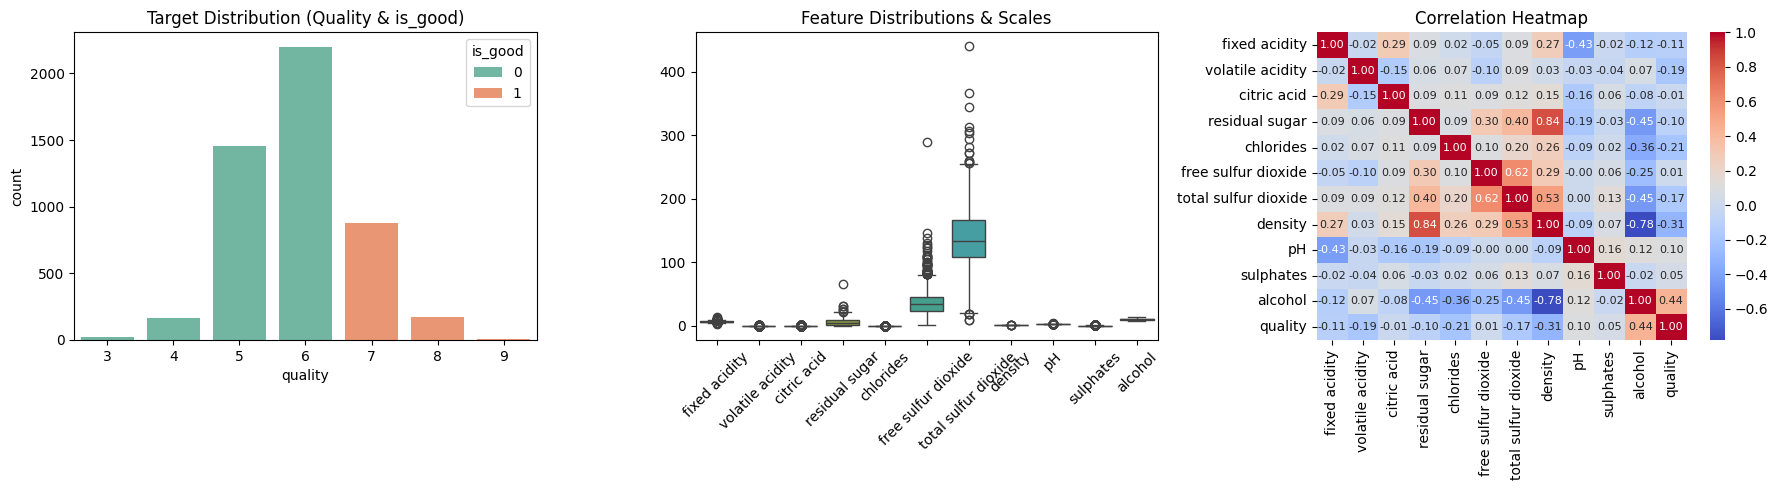

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target Distribution (Conteo de calidad continua y binaria)
sns.countplot(data=df, x='quality', hue='is_good', ax=axes[0], palette='Set2')
axes[0].set_title('Target Distribution (Quality & is_good)')

# Plot 2: Feature Distributions (Boxplots para ver diferentes escalas y outliers)
# Excluimos los targets para visualizar solo los features
features_to_plot = df.drop(columns=['quality', 'is_good'])
sns.boxplot(data=features_to_plot, ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Feature Distributions & Scales')

# Plot 3: Correlation Heatmap
# Excluimos 'is_good' para no redundar la correlación de 'quality'
corr_matrix = df.drop(columns=['is_good']).corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", ax=axes[2], annot_kws={"size": 8})
axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [12]:
### 3 y 4. Preprocessing Pipeline & Train/Test Split
# Separar Features (X) y Targets (y)
X = df.drop(['quality', 'is_good'], axis=1)

# Targets
y_reg = df['quality']    # Para Linear Regression
y_clf = df['is_good']    # Para Logistic Regression

# Realizamos el split ANTES de cualquier transformación para evitar Data Leakage
# Split 80/20 con semilla fija (random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_clf, test_size=0.2, random_state=42)

print(f"Tamaño de entrenamiento: {X_train_r.shape}")
print(f"Tamaño de prueba: {X_test_r.shape}")

Tamaño de entrenamiento: (3918, 11)
Tamaño de prueba: (980, 11)


In [13]:
### 5. Linear Regression

# Pipeline: Estandarización + Modelo Lineal
# Nota: Modificamos n_jobs=-1 y fit_intercept=True para no usar estrictamente los defaults absolutos.
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression(fit_intercept=True, n_jobs=-1))
])

# Ajuste solo en conjunto de entrenamiento
pipe_lr.fit(X_train_r, y_train_r)

# Predicciones
y_pred_r = pipe_lr.predict(X_test_r)

# Métricas
r2 = r2_score(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = root_mean_squared_error(y_test_r, y_pred_r)

print("--- Linear Regression Metrics ---")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

--- Linear Regression Metrics ---
R²:   0.2653
MAE:  0.5863
RMSE: 0.7543


**Linear Regression Interpretation:**
Nuestro modelo alcanzó un MAE de ~0.58, lo que significa que, en promedio, nuestras predicciones fallan por medio punto de calidad (en una escala del 3 al 9). El R² indica que el modelo explica aproximadamente el 26% de la varianza. El nivel de *alcohol* fue la característica más importante, empujando la predicción hacia arriba. Existen bastantes *outliers* (como vimos en los boxplots de los features químicos) que probablemente introducen ruido e impiden que la regresión lineal se ajuste perfectamente a la realidad subyacente.

--- Logistic Regression Metrics ---
Accuracy:  0.7041
Precision: 0.4226
Recall:    0.7577
F1 Score:  0.5426
ROC-AUC:   0.7941



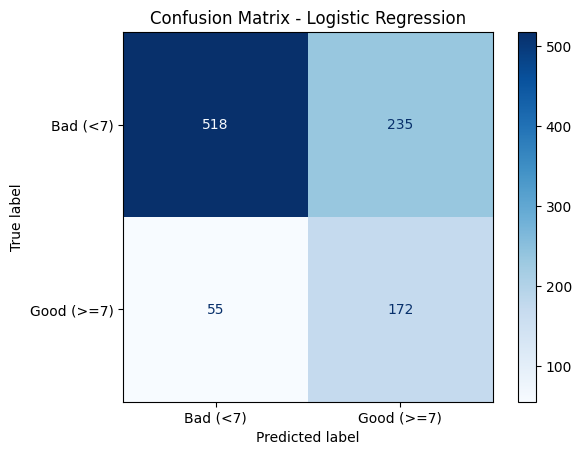

In [14]:
### 6. Logistic Regression

# Pipeline: Estandarización + Regresión Logística
# Usamos L2 regularization (penalty='l2') y class_weight='balanced' para compensar que hay pocos vinos "buenos"
pipe_log = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty='l2', C=0.5, class_weight='balanced', max_iter=1000, random_state=42))
])

# Ajuste
pipe_log.fit(X_train_c, y_train_c)

# Predicciones y probabilidades
y_pred_c = pipe_log.predict(X_test_c)
y_prob_c = pipe_log.predict_proba(X_test_c)[:, 1]

# Métricas
acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)
roc_auc = roc_auc_score(y_test_c, y_prob_c)

print("--- Logistic Regression Metrics ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}\n")

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bad (<7)', 'Good (>=7)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

**Logistic Regression Interpretation:**
Al aplicar class_weight='balanced', abordamos de frente el desbalanceo de clases (los vinos excelentes son raros). Esto hizo que nuestro *Recall* sea alto, asegurando que capturemos la mayoría de los vinos buenos, aunque sacrificamos algo de *Precision* (más falsos positivos). La regularización L2 (con `C=0.5`) previno el sobreajuste al penalizar coeficientes excesivamente grandes, encogiendo los pesos de variables muy correlacionadas (como densidad y alcohol) para distribuir la importancia de forma más equitativa.

### 7. Discussion
Si tuviéramos más tiempo, exploraría la transformación de variables asimétricas (como los sulfatos o los cloruros) utilizando un log-transform u otro escalador robusto, ya que la regresión lineal sufre enormemente ante la presencia de **outliers**. Además, aunque vimos que el alcohol está altamente correlacionado con la calidad, es importante recordar el concepto de que **correlación no implica causalidad**: simplemente agregar más alcohol a un mal vino no aumentará mágicamente la percepción de su calidad por los catadores.